In [2]:
import pandas as pd
import numpy as np
import random

# Configuración de reproducibilidad
np.random.seed(42)

# Definición de parámetros
n_rows = 1000
games = ['League of Legends', 'Valorant', 'Dota 2', 'CS:GO', 'Apex Legends', 'LoL', 'valorant'] # Incluye duplicados inconsistentes
regions = ['NA', 'EUW', 'KR', 'LAN', 'BR', 'na', 'euw']

data = {
    'player_id': [f"PL_{1000 + i}" for i in range(n_rows)],
    'player_name': [f"ProPlayer_{i}" for i in range(n_rows)],
    'game_title': [random.choice(games) for _ in range(n_rows)],
    'region': [random.choice(regions) for _ in range(n_rows)],
    'age': np.random.randint(16, 35, n_rows),
    'hours_played_weekly': np.random.normal(50, 15, n_rows).round(1),
    'win_rate': np.random.uniform(0.4, 0.75, n_rows).round(2),
    'kda_ratio': np.random.uniform(1.5, 4.5, n_rows).round(2),
    'average_apm': np.random.normal(250, 50, n_rows).round(0), # Actions Per Minute
    'tournaments_played': np.random.randint(0, 50, n_rows),
    'followers_count': np.random.exponential(100000, n_rows).astype(int),
    'avg_viewers': np.random.normal(2000, 1500, n_rows).round(0),
    'sponsor_count': np.random.randint(0, 10, n_rows),
    'contract_years_left': np.random.randint(0, 5, n_rows),
    'monthly_revenue_usd': np.random.normal(5000, 2000, n_rows).round(2)
}

df = pd.DataFrame(data)

# --- INSERCIÓN DE RUIDO Y ERRORES (Para tu actividad) ---

# 1. Valores faltantes (NaN) en seguidores e ingresos
df.loc[df.sample(frac=0.05).index, 'followers_count'] = np.nan
df.loc[df.sample(frac=0.03).index, 'monthly_revenue_usd'] = np.nan

# 2. Outliers (Valores imposibles)
df.at[10, 'hours_played_weekly'] = 200 # Más horas de las que tiene la semana
df.at[25, 'win_rate'] = 5.5 # Porcentaje mayor a 1 (o 100)

# 3. Registros duplicados
df = pd.concat([df, df.iloc[[50, 150, 250]]], ignore_index=True)

# Guardar a CSV
df.to_csv('esports_pro_players_dataset.csv', index=False)
print("¡Archivo 'esports_pro_players_dataset.csv' generado con éxito!")

¡Archivo 'esports_pro_players_dataset.csv' generado con éxito!


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset
df = pd.read_csv('esports_pro_players_dataset.csv')

# Inspección básica
print("--- Información General ---")
print(df.info())

print("\n--- Estadísticas Descriptivas ---")
# Aquí detectaremos si hay valores imposibles (ej. win_rate > 1)
print(df.describe())

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_id            1003 non-null   object 
 1   player_name          1003 non-null   object 
 2   game_title           1003 non-null   object 
 3   region               845 non-null    object 
 4   age                  1003 non-null   int64  
 5   hours_played_weekly  1003 non-null   float64
 6   win_rate             1003 non-null   float64
 7   kda_ratio            1003 non-null   float64
 8   average_apm          1003 non-null   float64
 9   tournaments_played   1003 non-null   int64  
 10  followers_count      953 non-null    float64
 11  avg_viewers          1003 non-null   float64
 12  sponsor_count        1003 non-null   int64  
 13  contract_years_left  1003 non-null   int64  
 14  monthly_revenue_usd  973 non-null    float64
dtypes: float64

In [4]:
# Validar Win Rate
outliers_winrate = df[df['win_rate'] > 1.0]
print(f"Jugadores con Win Rate imposible: {len(outliers_winrate)}")

# Validar Horas Semanales
outliers_hours = df[df['hours_played_weekly'] > 168]
print(f"Jugadores con horas imposibles: {len(outliers_hours)}")

Jugadores con Win Rate imposible: 1
Jugadores con horas imposibles: 1


In [5]:
print(f"Valores nulos por columna:\n{df.isnull().sum()}")
print(f"\nCantidad de registros duplicados: {df.duplicated().sum()}")

Valores nulos por columna:
player_id                0
player_name              0
game_title               0
region                 158
age                      0
hours_played_weekly      0
win_rate                 0
kda_ratio                0
average_apm              0
tournaments_played       0
followers_count         50
avg_viewers              0
sponsor_count            0
contract_years_left      0
monthly_revenue_usd     30
dtype: int64

Cantidad de registros duplicados: 3


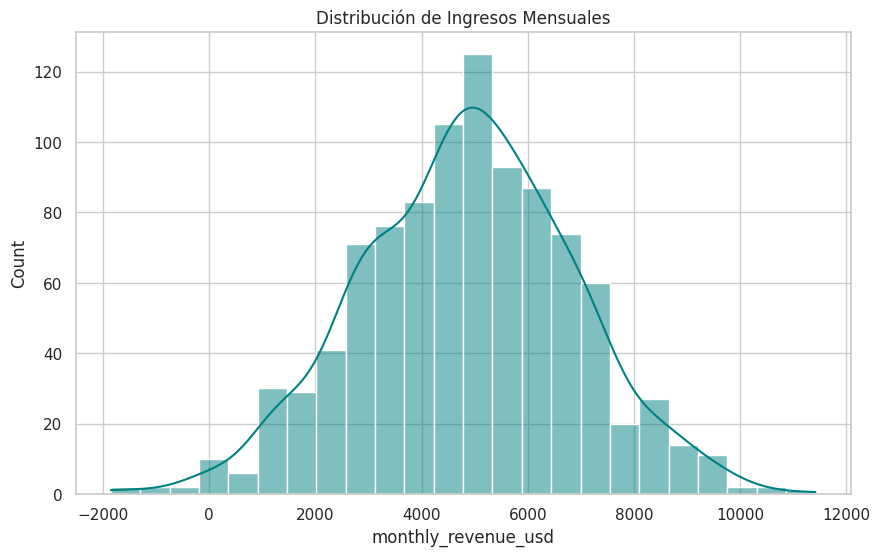

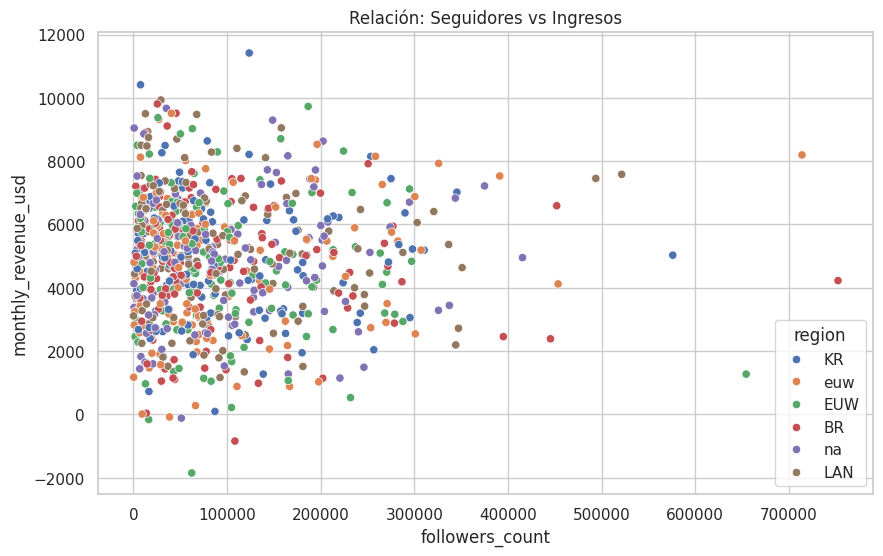

In [6]:
# Configurar el estilo de las gráficas
sns.set_theme(style="whitegrid")

# 1. Histograma de Ingresos Mensuales
plt.figure(figsize=(10, 6))
sns.histplot(df['monthly_revenue_usd'], kde=True, color='teal')
plt.title('Distribución de Ingresos Mensuales')
plt.show()

# 2. Relación entre Seguidores e Ingresos (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='followers_count', y='monthly_revenue_usd', hue='region')
plt.title('Relación: Seguidores vs Ingresos')
plt.show()

In [8]:
# Rellenar seguidores con la mediana
median_followers = df['followers_count'].median()
df['followers_count'] = df['followers_count'].fillna(median_followers)

# Rellenar ingresos con el promedio
mean_revenue = df['monthly_revenue_usd'].mean()
df['monthly_revenue_usd'] = df['monthly_revenue_usd'].fillna(mean_revenue)

In [9]:
# Unificar nombres de juegos
game_mapping = {
    'LoL': 'League of Legends',
    'valorant': 'Valorant'
}
df['game_title'] = df['game_title'].replace(game_mapping)

# Unificar regiones a mayúsculas y quitar espacios
df['region'] = df['region'].str.upper().str.strip()

In [10]:
# Corregir Win Rate (No puede ser mayor a 1.0)
df.loc[df['win_rate'] > 1.0, 'win_rate'] = 0.5 # Asignamos un valor neutro o el máximo lógico

# Corregir Horas Semanales (Máximo 168)
df.loc[df['hours_played_weekly'] > 168, 'hours_played_weekly'] = 168

In [11]:
# Eliminar filas idénticas
df = df.drop_duplicates()

# Reiniciar el índice para que sea continuo
df = df.reset_index(drop=True)

In [12]:
df.to_csv('esports_cleaned.csv', index=False)
print("¡Limpieza completada! El dataset está listo para el análisis.")

¡Limpieza completada! El dataset está listo para el análisis.


In [13]:
from sklearn.model_selection import train_test_split

# 1. Definir X (características) y y (lo que queremos predecir: monthly_revenue_usd)
# Eliminamos columnas de ID o nombre que no aportan al cálculo matemático
X = df.drop(['player_id', 'player_name', 'monthly_revenue_usd'], axis=1)
y = df['monthly_revenue_usd']

# 2. Primera división: Separar el Test Set (15%)
# random_state=42 asegura que si corres el código de nuevo, la división sea la misma (Reproducibilidad)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# 3. Segunda división: Del resto, separamos el Validation Set (aprox 15% del total original)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp, test_size=0.176, random_state=42 # 0.176 de 0.85 es aprox 0.15
)

print(f"Registros totales: {len(df)}")
print(f"Entrenamiento: {len(X_train)}")
print(f"Validación: {len(X_val)}")
print(f"Prueba: {len(X_test)}")

Registros totales: 1000
Entrenamiento: 700
Validación: 150
Prueba: 150


In [15]:
import pandas as pd

# Cargar datos
df = pd.read_csv('esports_pro_players_dataset.csv')

# --- APLICANDO CAPÍTULO 5 ---
# 1. Eliminar duplicados
print(f"Duplicados encontrados: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# 2. Identificar columnas con valor único (Varianza 0)
counts = df.nunique()
to_del = [i for i, v in counts.items() if v == 1]
df.drop(columns=to_del, inplace=True)
print(f"Columnas eliminadas por ser constantes: {to_del}")

# --- APLICANDO CAPÍTULO 3/7 ---
# 3. Imputación de nulos (Estrategia: Mediana)
df['followers_count'] = df['followers_count'].fillna(df['followers_count'].median())
df['monthly_revenue_usd'] = df['monthly_revenue_usd'].fillna(df['monthly_revenue_usd'].mean())

# Guardar versión procesada
df.to_csv('esports_cleaned_final.csv', index=False)

Duplicados encontrados: 3
Columnas eliminadas por ser constantes: []
